In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("AirPassengers.csv")
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.dtypes

Month            str
#Passengers    int64
dtype: object

In [10]:
# Change the #passengers column name to Passengers
df.columns = ["Month", "Passengers"]
df.head()

# Convert date (month variable) from str to datetime
df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values("Month")
df.head()

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [11]:
# Feature Engineer
df["Month_num"] = df["Month"].dt.month      # 1–12 (captures seasonality)
df["Year"]      = df["Month"].dt.year       # captures trend

df.head()


,Month,Passengers,Month_num,Year
0,1949-01-01,112,1,1949
1,1949-02-01,118,2,1949
2,1949-03-01,132,3,1949
3,1949-04-01,129,4,1949
4,1949-05-01,121,5,1949


In [12]:
df["Lag_1"]     = df["Passengers"].shift(1) # last month
df["Lag_12"]    = df["Passengers"].shift(12) # same month last year ← KEY feature

In [16]:
df.head()

,Month,Passengers,Month_num,Year,Lag_1,Lag_12
0,1949-01-01,112,1,1949,NaN,NaN
1,1949-02-01,118,2,1949,112.0,NaN
2,1949-03-01,132,3,1949,118.0,NaN
3,1949-04-01,129,4,1949,132.0,NaN
4,1949-05-01,121,5,1949,129.0,NaN


In [20]:
# Drop Rows with null values
df.shape
df.isnull().sum()
df = df.dropna()
df.value_counts()


Month       Passengers  Month_num  Year  Lag_1  Lag_12
1950-01-01  115         1          1950  118.0  112.0     1
1950-02-01  126         2          1950  115.0  118.0     1
1950-03-01  141         3          1950  126.0  132.0     1
1950-04-01  135         4          1950  141.0  129.0     1
1950-05-01  125         5          1950  135.0  121.0     1
                                                         ..
1960-08-01  606         8          1960  622.0  559.0     1
1960-09-01  508         9          1960  606.0  463.0     1
1960-10-01  461         10         1960  508.0  407.0     1
1960-11-01  390         11         1960  461.0  362.0     1
1960-12-01  432         12         1960  390.0  405.0     1
Name: count, Length: 132, dtype: int64

In [24]:
df.head()

,Month,Passengers,Month_num,Year,Lag_1,Lag_12
12,1950-01-01,115,1,1950,118.0,112.0
13,1950-02-01,126,2,1950,115.0,118.0
14,1950-03-01,141,3,1950,126.0,132.0
15,1950-04-01,135,4,1950,141.0,129.0
16,1950-05-01,125,5,1950,135.0,121.0


In [ ]:
# Drop Month Column
df = df.drop(columns= ["Month"])
df.head()

,Passengers,Month_num,Year,Lag_1,Lag_12
12,115,1,1950,118.0,112.0
13,126,2,1950,115.0,118.0
14,141,3,1950,126.0,132.0
15,135,4,1950,141.0,129.0
16,125,5,1950,135.0,121.0


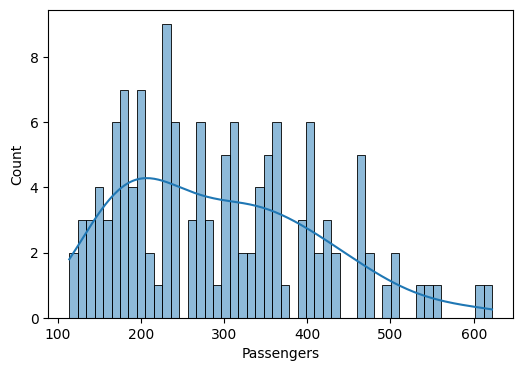

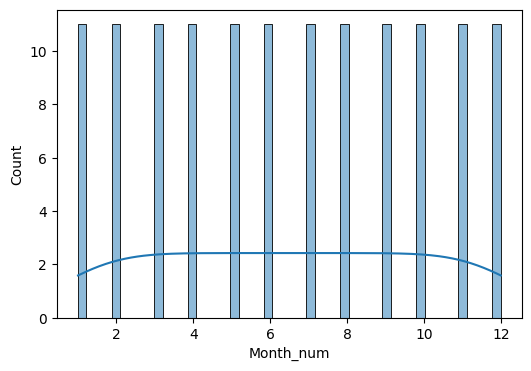

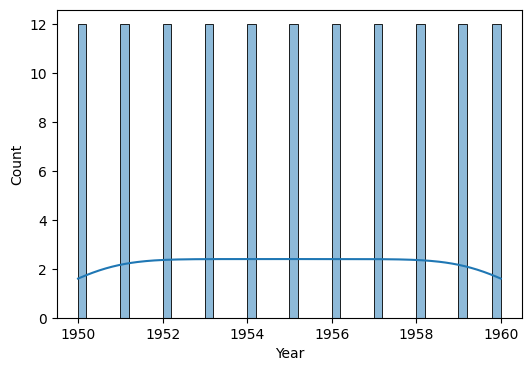

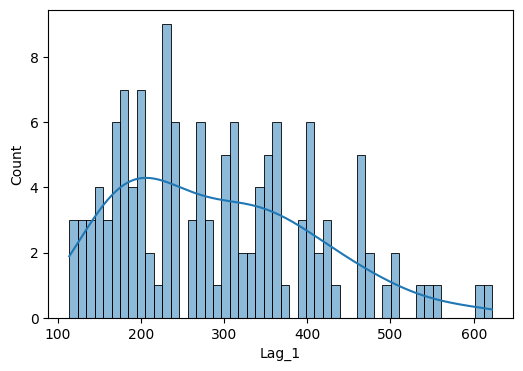

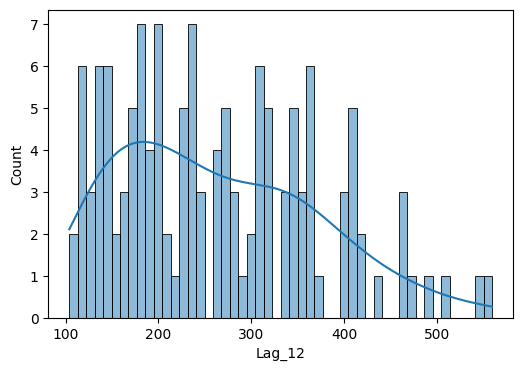

In [40]:
# Distribution of continuous column
for col in df:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde = True, bins = 50)

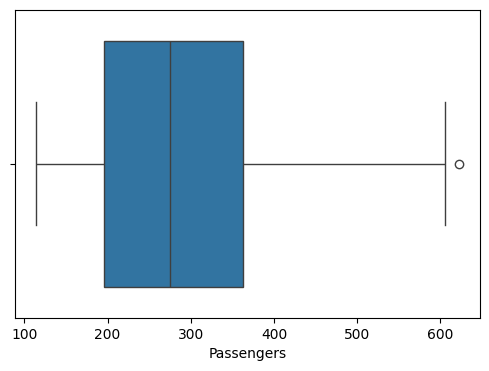

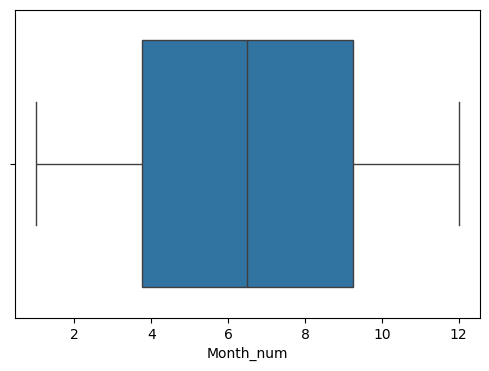

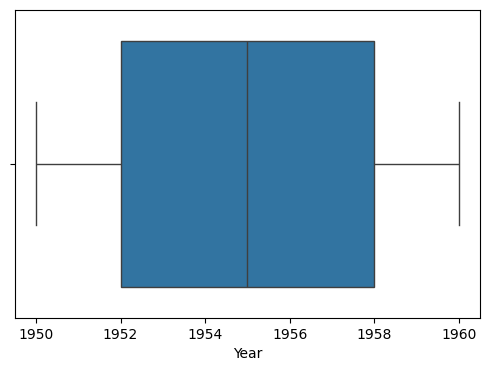

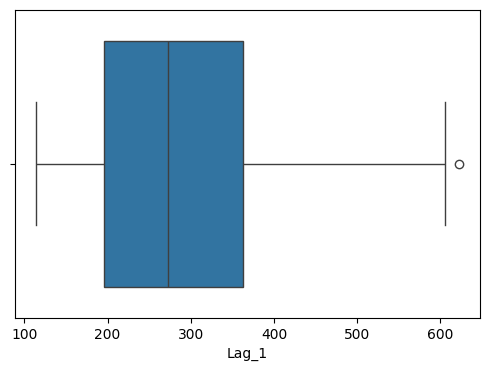

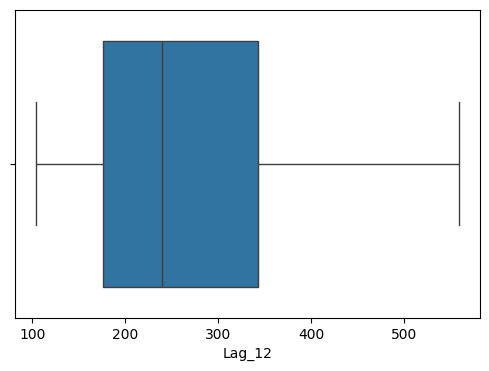

In [ ]:
# Check Outliers
for col in df:
    plt.figure(figsize = (6,4))
    sns.boxplot(x = df[col])

<Axes: >

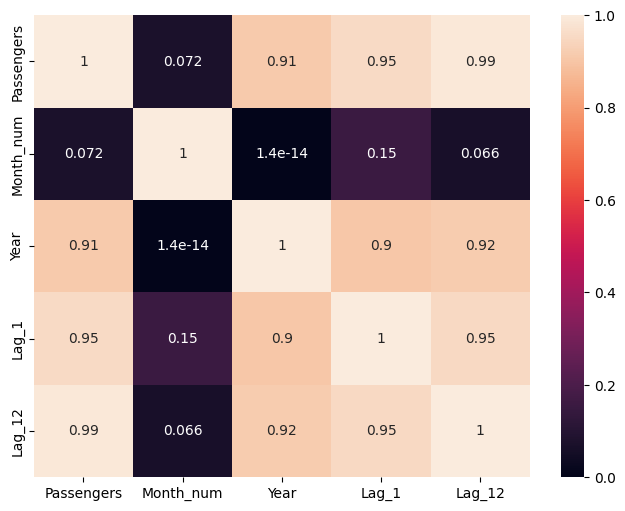

In [31]:
# Check Correlation between the Each Variable
plt.figure(figsize= (8,6))
sns.heatmap(df.corr(numeric_only = True), annot= True)

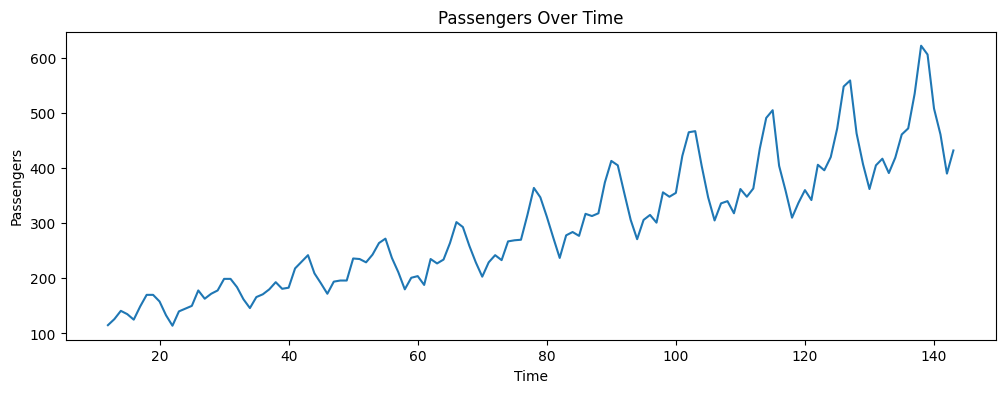

In [42]:
# Passengers over time — MUST HAVE for time series!
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Passengers'])
plt.title("Passengers Over Time")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.show()

In [48]:
print(df.min())
print(df.max())

Passengers     114.0
Month_num        1.0
Year          1950.0
Lag_1          114.0
Lag_12         104.0
dtype: float64
Passengers     622.0
Month_num       12.0
Year          1960.0
Lag_1          622.0
Lag_12         559.0
dtype: float64


In [49]:
df.head()

,Passengers,Month_num,Year,Lag_1,Lag_12
12,115,1,1950,118.0,112.0
13,126,2,1950,115.0,118.0
14,141,3,1950,126.0,132.0
15,135,4,1950,141.0,129.0
16,125,5,1950,135.0,121.0


In [51]:
X = df[["Month_num","Year","Lag_1","Lag_12"]]
y = df["Passengers"]

In [52]:
# Time-based split
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train)} rows")
print(f"Test:  {len(X_test)} rows")

Train: 105 rows
Test:  27 rows


In [60]:
# Linear Regression Algorithm
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
# Make Predaction
y_pred_lr = lr.predict(X_test)

In [62]:
# Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

MAE: 15.502536096459798
MSE: 345.0893163463153
R2 Score: 0.9456701780190185


In [63]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.6803142643956579


In [64]:
# XGBoost
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGB R2:", r2_score(y_test, y_pred_xgb))

XGB R2: 0.5406445264816284


In [65]:
results = { 
    "Linear Regression": r2_score(y_test, y_pred_lr),
    "Random Forest":     r2_score(y_test, y_pred_rf),
    "XGBoost":           r2_score(y_test, y_pred_xgb)
}

for model, score in results.items():
    print(f"{model}: R2 = {score:.4f}")

Linear Regression: R2 = 0.9457
Random Forest: R2 = 0.6803
XGBoost: R2 = 0.5406
